Loan default risk data

In [1]:
import sys
!python.exe -m pip install --upgrade pip

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

Loading Data Set

In [4]:
df = pd.read_csv("loan_default_risk_data.csv")

Exploratory Data Analysis

In [5]:
df.head()

,Loan_ID,Customer_ID,Age,Gender,City,Income,Employment_Type,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Existing_Loans,Debt_to_Income,Payment_History,Loan_Purpose,Default_Flag,Application_Date
0,L0,573890,29,Male,Chennai,60745,Unemployed,722,324677,12,11.70,30222.02,5,1.00,18,Home,0,2017-09-06
1,L1,618322,22,Other,Bhopal,83424,Self-Employed,387,155281,36,15.96,5001.77,3,0.71,23,Education,1,2016-12-18
2,L2,734045,29,Other,Mumbai,113963,Unemployed,493,79923,36,17.37,2605.71,0,0.68,32,Car,0,2022-08-16
3,L3,302103,35,Male,Mumbai,53137,Unemployed,465,225259,60,7.61,4040.02,5,0.16,32,Car,0,2021-06-18
4,L4,91731,38,Male,Bhopal,38439,Salaried,789,407615,12,7.05,36362.65,4,0.32,1,Car,1,2021-04-29


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Loan_ID           95000 non-null  object 
 1   Customer_ID       95000 non-null  int64  
 2   Age               95000 non-null  int64  
 3   Gender            95000 non-null  object 
 4   City              95000 non-null  object 
 5   Income            95000 non-null  int64  
 6   Employment_Type   95000 non-null  object 
 7   Credit_Score      95000 non-null  int64  
 8   Loan_Amount       95000 non-null  int64  
 9   Loan_Term_Months  95000 non-null  int64  
 10  Interest_Rate     95000 non-null  float64
 11  EMI               95000 non-null  float64
 12  Existing_Loans    95000 non-null  int64  
 13  Debt_to_Income    95000 non-null  float64
 14  Payment_History   95000 non-null  int64  
 15  Loan_Purpose      95000 non-null  object 
 16  Default_Flag      95000 non-null  int64 

In [9]:
df.describe()

,Customer_ID,Age,Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Existing_Loans,Debt_to_Income,Payment_History,Default_Flag
count,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000
mean,499969.892600,41.493621,104938.545105,599.228347,252601.801389,32.945053,11.501819,11945.478881,2.503484,0.500033,49.936905,0.498905
std,288552.784089,13.867253,54917.313222,173.416088,143127.019726,17.776559,3.760803,10613.778795,1.707512,0.288904,29.139272,0.500001
min,1009.000000,18.000000,10003.000000,300.000000,5001.000000,12.000000,5.000000,92.470000,0.000000,0.000000,0.000000,0.000000
25%,249780.250000,29.000000,57245.750000,449.000000,128373.750000,12.000000,8.250000,4330.120000,1.000000,0.250000,25.000000,0.000000
50%,499017.500000,42.000000,104968.500000,598.000000,252353.500000,24.000000,11.510000,8549.065000,3.000000,0.500000,50.000000,0.000000
75%,750693.000000,54.000000,152717.250000,749.000000,376580.000000,60.000000,14.750000,15784.355000,4.000000,0.750000,75.000000,1.000000
max,999998.000000,65.000000,200000.000000,900.000000,500000.000000,60.000000,18.000000,49065.680000,5.000000,1.000000,100.000000,1.000000


In [8]:
df.drop_duplicates()

,Loan_ID,Customer_ID,Age,Gender,City,Income,Employment_Type,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Existing_Loans,Debt_to_Income,Payment_History,Loan_Purpose,Default_Flag,Application_Date
0,L0,573890,29,Male,Chennai,60745,Unemployed,722,324677,12,11.70,30222.02,5,1.00,18,Home,0,2017-09-06
1,L1,618322,22,Other,Bhopal,83424,Self-Employed,387,155281,36,15.96,5001.77,3,0.71,23,Education,1,2016-12-18
2,L2,734045,29,Other,Mumbai,113963,Unemployed,493,79923,36,17.37,2605.71,0,0.68,32,Car,0,2022-08-16
3,L3,302103,35,Male,Mumbai,53137,Unemployed,465,225259,60,7.61,4040.02,5,0.16,32,Car,0,2021-06-18
4,L4,91731,38,Male,Bhopal,38439,Salaried,789,407615,12,7.05,36362.65,4,0.32,1,Car,1,2021-04-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,L94995,556371,20,Other,Kolkata,134094,Self-Employed,860,102145,36,10.52,3135.85,2,0.39,45,Personal,1,2022-08-21
94996,L94996,966331,60,Female,Kolkata,167802,Self-Employed,676,430397,24,11.84,20056.50,5,0.42,94,Business,0,2016-06-30
94997,L94997,361133,57,Male,Mumbai,113700,Unemployed,653,467880,12,12.16,43731.18,0,0.85,99,Business,1,2018-05-24
94998,L94998,934984,22,Other,Bhopal,170375,Salaried,521,177517,24,14.65,8480.14,4,0.76,73,Personal,1,2019-04-05


In [10]:
df.shape

(95000, 18)

In [11]:
df.columns

Index(['Loan_ID', 'Customer_ID', 'Age', 'Gender', 'City', 'Income',
       'Employment_Type', 'Credit_Score', 'Loan_Amount', 'Loan_Term_Months',
       'Interest_Rate', 'EMI', 'Existing_Loans', 'Debt_to_Income',
       'Payment_History', 'Loan_Purpose', 'Default_Flag', 'Application_Date'],
      dtype='object')

In [12]:
df.nunique()

Loan_ID             95000
Customer_ID         90591
Age                    48
Gender                  3
City                    5
Income              74639
Employment_Type         3
Credit_Score          601
Loan_Amount         86328
Loan_Term_Months        4
Interest_Rate        1301
EMI                 93207
Existing_Loans          6
Debt_to_Income        101
Payment_History       101
Loan_Purpose            5
Default_Flag            2
Application_Date     3001
dtype: int64

Data Cleaning

In [13]:
df.isnull()

,Loan_ID,Customer_ID,Age,Gender,City,Income,Employment_Type,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Existing_Loans,Debt_to_Income,Payment_History,Loan_Purpose,Default_Flag,Application_Date
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
94996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
94997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
94998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
df.dropna()

,Loan_ID,Customer_ID,Age,Gender,City,Income,Employment_Type,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Existing_Loans,Debt_to_Income,Payment_History,Loan_Purpose,Default_Flag,Application_Date
0,L0,573890,29,Male,Chennai,60745,Unemployed,722,324677,12,11.70,30222.02,5,1.00,18,Home,0,2017-09-06
1,L1,618322,22,Other,Bhopal,83424,Self-Employed,387,155281,36,15.96,5001.77,3,0.71,23,Education,1,2016-12-18
2,L2,734045,29,Other,Mumbai,113963,Unemployed,493,79923,36,17.37,2605.71,0,0.68,32,Car,0,2022-08-16
3,L3,302103,35,Male,Mumbai,53137,Unemployed,465,225259,60,7.61,4040.02,5,0.16,32,Car,0,2021-06-18
4,L4,91731,38,Male,Bhopal,38439,Salaried,789,407615,12,7.05,36362.65,4,0.32,1,Car,1,2021-04-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,L94995,556371,20,Other,Kolkata,134094,Self-Employed,860,102145,36,10.52,3135.85,2,0.39,45,Personal,1,2022-08-21
94996,L94996,966331,60,Female,Kolkata,167802,Self-Employed,676,430397,24,11.84,20056.50,5,0.42,94,Business,0,2016-06-30
94997,L94997,361133,57,Male,Mumbai,113700,Unemployed,653,467880,12,12.16,43731.18,0,0.85,99,Business,1,2018-05-24
94998,L94998,934984,22,Other,Bhopal,170375,Salaried,521,177517,24,14.65,8480.14,4,0.76,73,Personal,1,2019-04-05


In [15]:
df.drop_duplicates()

,Loan_ID,Customer_ID,Age,Gender,City,Income,Employment_Type,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Existing_Loans,Debt_to_Income,Payment_History,Loan_Purpose,Default_Flag,Application_Date
0,L0,573890,29,Male,Chennai,60745,Unemployed,722,324677,12,11.70,30222.02,5,1.00,18,Home,0,2017-09-06
1,L1,618322,22,Other,Bhopal,83424,Self-Employed,387,155281,36,15.96,5001.77,3,0.71,23,Education,1,2016-12-18
2,L2,734045,29,Other,Mumbai,113963,Unemployed,493,79923,36,17.37,2605.71,0,0.68,32,Car,0,2022-08-16
3,L3,302103,35,Male,Mumbai,53137,Unemployed,465,225259,60,7.61,4040.02,5,0.16,32,Car,0,2021-06-18
4,L4,91731,38,Male,Bhopal,38439,Salaried,789,407615,12,7.05,36362.65,4,0.32,1,Car,1,2021-04-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,L94995,556371,20,Other,Kolkata,134094,Self-Employed,860,102145,36,10.52,3135.85,2,0.39,45,Personal,1,2022-08-21
94996,L94996,966331,60,Female,Kolkata,167802,Self-Employed,676,430397,24,11.84,20056.50,5,0.42,94,Business,0,2016-06-30
94997,L94997,361133,57,Male,Mumbai,113700,Unemployed,653,467880,12,12.16,43731.18,0,0.85,99,Business,1,2018-05-24
94998,L94998,934984,22,Other,Bhopal,170375,Salaried,521,177517,24,14.65,8480.14,4,0.76,73,Personal,1,2019-04-05


In [16]:
df.describe()

,Customer_ID,Age,Income,Credit_Score,Loan_Amount,Loan_Term_Months,Interest_Rate,EMI,Existing_Loans,Debt_to_Income,Payment_History,Default_Flag
count,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000
mean,499969.892600,41.493621,104938.545105,599.228347,252601.801389,32.945053,11.501819,11945.478881,2.503484,0.500033,49.936905,0.498905
std,288552.784089,13.867253,54917.313222,173.416088,143127.019726,17.776559,3.760803,10613.778795,1.707512,0.288904,29.139272,0.500001
min,1009.000000,18.000000,10003.000000,300.000000,5001.000000,12.000000,5.000000,92.470000,0.000000,0.000000,0.000000,0.000000
25%,249780.250000,29.000000,57245.750000,449.000000,128373.750000,12.000000,8.250000,4330.120000,1.000000,0.250000,25.000000,0.000000
50%,499017.500000,42.000000,104968.500000,598.000000,252353.500000,24.000000,11.510000,8549.065000,3.000000,0.500000,50.000000,0.000000
75%,750693.000000,54.000000,152717.250000,749.000000,376580.000000,60.000000,14.750000,15784.355000,4.000000,0.750000,75.000000,1.000000
max,999998.000000,65.000000,200000.000000,900.000000,500000.000000,60.000000,18.000000,49065.680000,5.000000,1.000000,100.000000,1.000000


In [17]:
import pandas as pd

df = pd.read_csv("C:/Users/hp/OneDrive/Desktop/Project github/loan_default_risk_data.csv")
df["Application_Date"] = pd.to_datetime(df["Application_Date"])

In [18]:
#Total loan amount by city
city_loan = df.groupby("City")["Loan_Amount"].sum()
print(city_loan)

City
Bhopal     4770343445
Chennai    4814359913
Delhi      4809138772
Kolkata    4775040250
Mumbai     4828288752
Name: Loan_Amount, dtype: int64


In [19]:
#Average credit score by employment type
credit_emp = df.groupby("Employment_Type")["Credit_Score"].mean()
print(credit_emp)

Employment_Type
Salaried         599.690734
Self-Employed    598.480872
Unemployed       599.509944
Name: Credit_Score, dtype: float64


In [21]:
#Default count by loan purpose
default_purpose = df.groupby("Loan_Purpose")["Default_Flag"].sum()
print(default_purpose)

Loan_Purpose
Business     9273
Car          9435
Education    9517
Home         9606
Personal     9565
Name: Default_Flag, dtype: int64


In [22]:
#Loan summary by employment type
emp_summary = df.groupby("Employment_Type").agg({
    "Loan_Amount": ["sum", "mean", "max"],
    "Income": ["mean", "median"],
    "Credit_Score": ["mean", "min", "max"],
    "Default_Flag": "sum"
})

print(emp_summary)

                Loan_Amount                                Income            \
                        sum           mean     max           mean    median   
Employment_Type                                                               
Salaried         8036949951  254172.990228  500000  105317.542568  105143.0   
Self-Employed    7928349060  251286.775696  499994  105177.513359  105468.0   
Unemployed       8031872121  252344.469540  499997  104325.155204  104220.0   

                Credit_Score           Default_Flag  
                        mean  min  max          sum  
Employment_Type                                      
Salaried          599.690734  300  900        15765  
Self-Employed     598.480872  300  900        15930  
Unemployed        599.509944  300  900        15701  


In [23]:
#City-level risk summary
city_summary = df.groupby("City").agg({
    "Loan_Amount": "sum",
    "Credit_Score": "mean",
    "Debt_to_Income": "mean",
    "Default_Flag": "sum"
})

print(city_summary)

         Loan_Amount  Credit_Score  Debt_to_Income  Default_Flag
City                                                            
Bhopal    4770343445    599.171010        0.498380          9430
Chennai   4814359913    599.234138        0.500669          9683
Delhi     4809138772    599.646925        0.498942          9521
Kolkata   4775040250    598.398240        0.498150          9383
Mumbai    4828288752    599.686684        0.504000          9379


In [24]:
#Loan amount by city and gender
pivot_loan = pd.pivot_table(
    df,
    values="Loan_Amount",
    index="City",
    columns="Gender",
    aggfunc="sum",
    fill_value=0
)

print(pivot_loan)

Gender       Female        Male       Other
City                                       
Bhopal   1581772795  1620200897  1568369753
Chennai  1651228797  1554353212  1608777904
Delhi    1594370849  1640701642  1574066281
Kolkata  1598859813  1590395277  1585785160
Mumbai   1612477724  1629642849  1586168179


In [25]:
#Default count by purpose and employment
pivot_default = pd.pivot_table(
    df,
    values="Default_Flag",
    index="Loan_Purpose",
    columns="Employment_Type",
    aggfunc="sum",
    fill_value=0
)

print(pivot_default)

Employment_Type  Salaried  Self-Employed  Unemployed
Loan_Purpose                                        
Business             3060           3147        3066
Car                  3100           3192        3143
Education            3169           3236        3112
Home                 3256           3182        3168
Personal             3180           3173        3212


In [26]:
#Create average city income table
city_income = df.groupby("City")["Income"].mean().reset_index()
city_income.rename(columns={"Income": "City_Avg_Income"}, inplace=True)

In [27]:
#Merge back into original dataframe
df = pd.merge(df, city_income, on="City", how="left")
print(df.head())

  Loan_ID  Customer_ID  Age Gender     City  Income Employment_Type  \
0      L0       573890   29   Male  Chennai   60745      Unemployed   
1      L1       618322   22  Other   Bhopal   83424   Self-Employed   
2      L2       734045   29  Other   Mumbai  113963      Unemployed   
3      L3       302103   35   Male   Mumbai   53137      Unemployed   
4      L4        91731   38   Male   Bhopal   38439        Salaried   

   Credit_Score  Loan_Amount  Loan_Term_Months  Interest_Rate       EMI  \
0           722       324677                12          11.70  30222.02   
1           387       155281                36          15.96   5001.77   
2           493        79923                36          17.37   2605.71   
3           465       225259                60           7.61   4040.02   
4           789       407615                12           7.05  36362.65   

   Existing_Loans  Debt_to_Income  Payment_History Loan_Purpose  Default_Flag  \
0               5            1.00        

In [28]:
#Risk label from credit score
def risk_label(score):
    if score >= 750:
        return "Low Risk"
    elif score >= 650:
        return "Medium Risk"
    else:
        return "High Risk"

df["Risk_Level"] = df["Credit_Score"].apply(risk_label)

In [29]:
#Loan-to-income ratio
df["Loan_Income_Ratio"] = df.apply(
    lambda x: x["Loan_Amount"] / x["Income"],
    axis=1
)

In [30]:
df["Loan_Amount"].sum()
df["Loan_Amount"].mean()
df["Loan_Amount"].max()
df["Loan_Amount"].min()
df["Loan_Amount"].median()
df["Loan_Amount"].count()
df["Loan_Amount"].std()

np.float64(143127.01972592206)

In [31]:
#Which employment type is strongest?
loan_perf = df.groupby("Employment_Type").agg({
    "Loan_Amount": "sum",
    "Default_Flag": "sum",
    "Credit_Score": "mean"
})

loan_perf["Default_Rate"] = (
    loan_perf["Default_Flag"] /
    df.groupby("Employment_Type")["Loan_ID"].count()
)

print(loan_perf.sort_values("Default_Rate"))

                 Loan_Amount  Default_Flag  Credit_Score  Default_Rate
Employment_Type                                                       
Unemployed        8031872121         15701    599.509944      0.493292
Salaried          8036949951         15765    599.690734      0.498577
Self-Employed     7928349060         15930    598.480872      0.504897


In [32]:
#Most useful derived columns

df["Loan_Income_Ratio"] = df["Loan_Amount"] / df["Income"]
df["EMI_Income_Ratio"] = df["EMI"] / df["Income"]
df["Total_Debt_Exposure"] = df["Existing_Loans"] * df["EMI"]

In [34]:
df["Loan_Amount"]

0        324677
1        155281
2         79923
3        225259
4        407615
          ...  
94995    102145
94996    430397
94997    467880
94998    177517
94999    389875
Name: Loan_Amount, Length: 95000, dtype: int64

In [35]:
df[["Customer_ID", "City", "Income", "Loan_Amount", "Credit_Score"]]

,Customer_ID,City,Income,Loan_Amount,Credit_Score
0,573890,Chennai,60745,324677,722
1,618322,Bhopal,83424,155281,387
2,734045,Mumbai,113963,79923,493
3,302103,Mumbai,53137,225259,465
4,91731,Bhopal,38439,407615,789
...,...,...,...,...,...
94995,556371,Kolkata,134094,102145,860
94996,966331,Kolkata,167802,430397,676
94997,361133,Mumbai,113700,467880,653
94998,934984,Bhopal,170375,177517,521


In [36]:
df[df["Loan_Amount"] > 500000]

,Loan_ID,Customer_ID,Age,Gender,City,Income,Employment_Type,Credit_Score,Loan_Amount,Loan_Term_Months,...,Debt_to_Income,Payment_History,Loan_Purpose,Default_Flag,Application_Date,City_Avg_Income,Risk_Level,Loan_Income_Ratio,EMI_Income_Ratio,Total_Debt_Exposure


In [37]:
df[df["Credit_Score"] > 700]

,Loan_ID,Customer_ID,Age,Gender,City,Income,Employment_Type,Credit_Score,Loan_Amount,Loan_Term_Months,...,Debt_to_Income,Payment_History,Loan_Purpose,Default_Flag,Application_Date,City_Avg_Income,Risk_Level,Loan_Income_Ratio,EMI_Income_Ratio,Total_Debt_Exposure
0,L0,573890,29,Male,Chennai,60745,Unemployed,722,324677,12,...,1.00,18,Home,0,2017-09-06,105145.072030,Medium Risk,5.344917,0.497523,151110.10
4,L4,91731,38,Male,Bhopal,38439,Salaried,789,407615,12,...,0.32,1,Car,1,2021-04-29,105057.151546,Low Risk,10.604204,0.945983,145450.60
9,L9,776928,44,Female,Kolkata,104902,Self-Employed,869,116890,12,...,0.63,24,Home,0,2018-12-18,104817.855629,Low Risk,1.114278,0.108438,56876.75
10,L10,401116,48,Male,Mumbai,21251,Salaried,793,397401,24,...,0.21,21,Home,1,2017-11-22,105215.611831,Low Risk,18.700344,0.846113,35961.48
21,L21,729511,31,Male,Chennai,40768,Unemployed,858,89954,60,...,0.52,97,Car,1,2023-03-10,105145.072030,Low Risk,2.206485,0.038768,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94982,L94982,775582,48,Other,Bhopal,148815,Unemployed,749,432859,12,...,0.53,70,Business,0,2017-05-26,105057.151546,Medium Risk,2.908705,0.255966,0.00
94985,L94985,354352,19,Other,Mumbai,35498,Unemployed,732,73573,60,...,0.09,40,Car,1,2021-11-02,105215.611831,Medium Risk,2.072596,0.039915,5667.56
94987,L94987,889264,35,Male,Kolkata,110333,Unemployed,864,213557,60,...,0.42,2,Car,1,2018-08-28,104817.855629,Low Risk,1.935568,0.037869,20891.20
94992,L94992,455080,21,Male,Kolkata,192196,Self-Employed,847,394012,24,...,0.48,72,Education,1,2016-04-02,104817.855629,Low Risk,2.050053,0.093346,0.00


In [38]:
df[df["Default_Flag"] == 1]

,Loan_ID,Customer_ID,Age,Gender,City,Income,Employment_Type,Credit_Score,Loan_Amount,Loan_Term_Months,...,Debt_to_Income,Payment_History,Loan_Purpose,Default_Flag,Application_Date,City_Avg_Income,Risk_Level,Loan_Income_Ratio,EMI_Income_Ratio,Total_Debt_Exposure
1,L1,618322,22,Other,Bhopal,83424,Self-Employed,387,155281,36,...,0.71,23,Education,1,2016-12-18,105057.151546,High Risk,1.861347,0.059956,15005.31
4,L4,91731,38,Male,Bhopal,38439,Salaried,789,407615,12,...,0.32,1,Car,1,2021-04-29,105057.151546,Low Risk,10.604204,0.945983,145450.60
5,L5,239631,54,Female,Mumbai,54966,Self-Employed,528,40349,60,...,0.11,75,Business,1,2018-05-01,105215.611831,High Risk,0.734072,0.014182,0.00
7,L7,43734,33,Female,Mumbai,34583,Unemployed,496,177367,24,...,0.25,70,Education,1,2019-05-14,105215.611831,High Risk,5.128734,0.243166,0.00
8,L8,999181,50,Female,Chennai,188577,Unemployed,658,430897,60,...,0.42,26,Home,1,2016-11-15,105145.072030,Medium Risk,2.284992,0.042261,7969.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94994,L94994,908050,39,Other,Kolkata,18647,Salaried,437,68253,36,...,0.33,46,Home,1,2021-01-17,104817.855629,High Risk,3.660267,0.113000,4214.24
94995,L94995,556371,20,Other,Kolkata,134094,Self-Employed,860,102145,36,...,0.39,45,Personal,1,2022-08-21,104817.855629,Low Risk,0.761742,0.023385,6271.70
94997,L94997,361133,57,Male,Mumbai,113700,Unemployed,653,467880,12,...,0.85,99,Business,1,2018-05-24,105215.611831,Medium Risk,4.115040,0.384619,0.00
94998,L94998,934984,22,Other,Bhopal,170375,Salaried,521,177517,24,...,0.76,73,Personal,1,2019-04-05,105057.151546,High Risk,1.041919,0.049773,33920.56


In [39]:
#Top 10 largest loans
df.nlargest(10, "Loan_Amount")[
    ["Customer_ID", "City", "Loan_Amount", "Credit_Score"]
]

,Customer_ID,City,Loan_Amount,Credit_Score
94368,238973,Kolkata,500000,724
64907,167816,Kolkata,499998,827
62284,92831,Chennai,499997,403
19380,493355,Chennai,499994,868
91134,434396,Mumbai,499986,597
24213,610150,Bhopal,499983,554
79611,173185,Mumbai,499983,708
1083,207385,Mumbai,499979,432
63454,598965,Chennai,499979,375
22188,891277,Bhopal,499977,519


In [40]:
#Lowest credit score customers
df.nsmallest(10, "Credit_Score")[
    ["Customer_ID", "City", "Credit_Score", "Default_Flag"]
]

,Customer_ID,City,Credit_Score,Default_Flag
1707,524486,Chennai,300,0
1921,560660,Mumbai,300,1
2225,318322,Delhi,300,1
2283,45395,Mumbai,300,0
2314,532843,Kolkata,300,0
3176,14687,Chennai,300,1
3591,998500,Delhi,300,1
3809,646408,Bhopal,300,0
4028,948829,Kolkata,300,0
5414,179130,Mumbai,300,1


In [47]:
#High-risk customers
df[
    (df["Credit_Score"] < 9990) &
    (df["Debt_to_Income"] > 10000)
][["Customer_ID", "Loan_Amount", "Credit_Score", "Debt_to_Income"]]

,Customer_ID,Loan_Amount,Credit_Score,Debt_to_Income


Visualization Dashboards

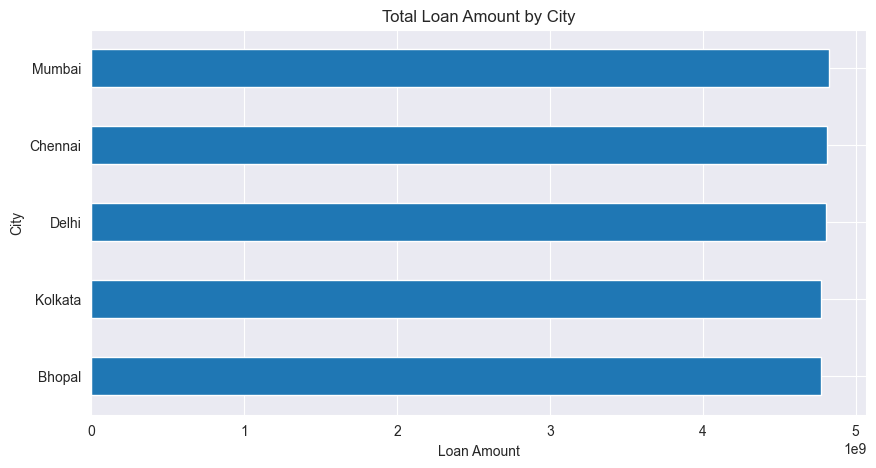

In [48]:
#Loan amount by citycity_loan = df.groupby("City")["Loan_Amount"].sum().sort_values()

plt.figure(figsize=(10,5))
city_loan.plot(kind="barh")
plt.title("Total Loan Amount by City")
plt.xlabel("Loan Amount")
plt.show()

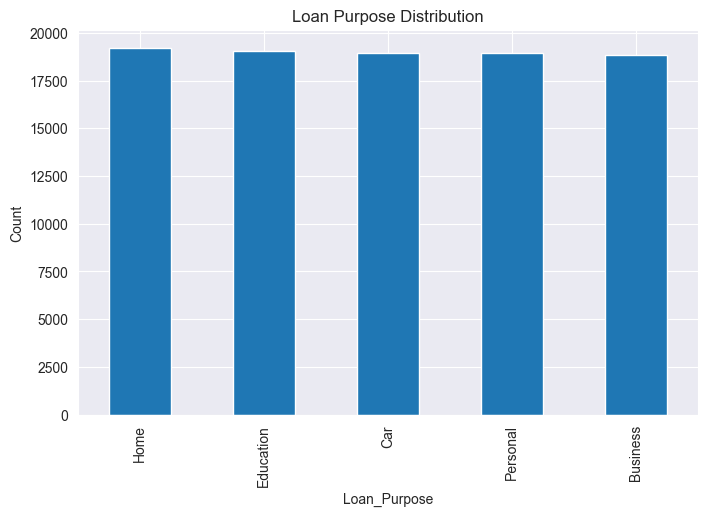

In [49]:
#Loan purpose distribution
purpose_count = df["Loan_Purpose"].value_counts()

plt.figure(figsize=(8,5))
purpose_count.plot(kind="bar")
plt.title("Loan Purpose Distribution")
plt.ylabel("Count")
plt.show()

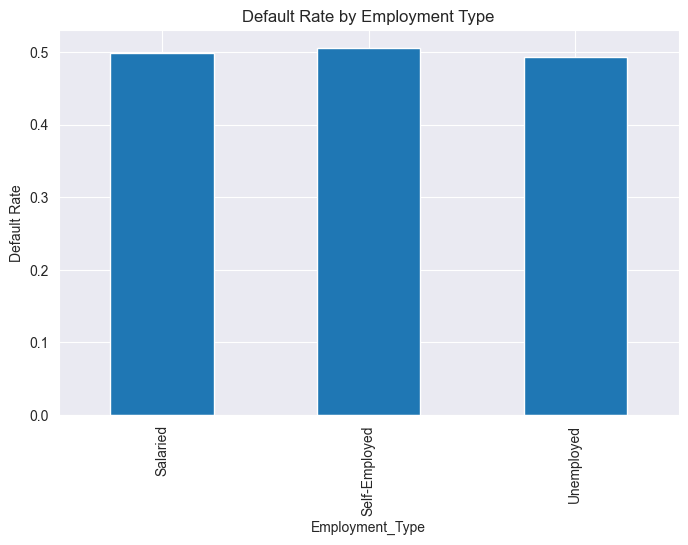

In [50]:
#Default rate by employment type
default_emp = df.groupby("Employment_Type")["Default_Flag"].mean()

plt.figure(figsize=(8,5))
default_emp.plot(kind="bar")
plt.title("Default Rate by Employment Type")
plt.ylabel("Default Rate")
plt.show()

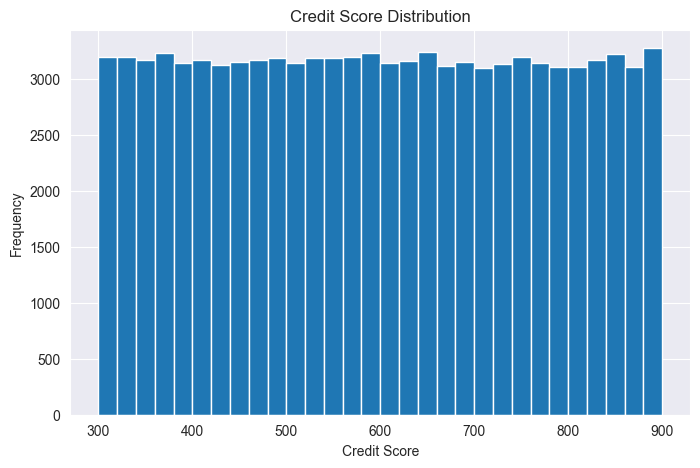

In [51]:
#Credit score distribution
plt.figure(figsize=(8,5))
df["Credit_Score"].plot(kind="hist", bins=30)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.show()

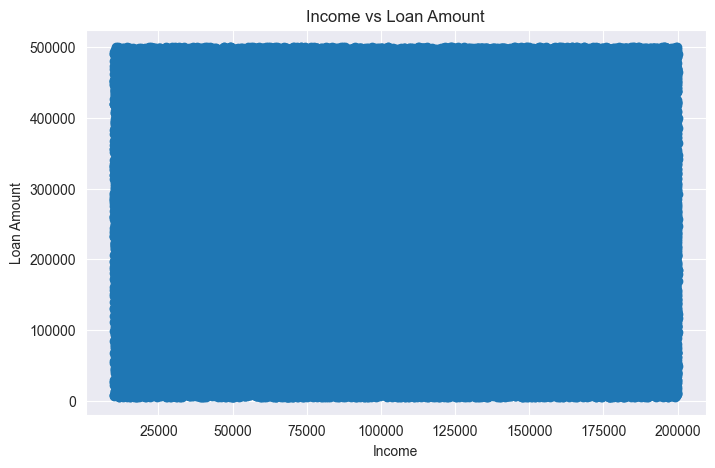

In [53]:
#Income vs loan amount
plt.figure(figsize=(8,5))
plt.scatter(df["Income"], df["Loan_Amount"])
plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.show()

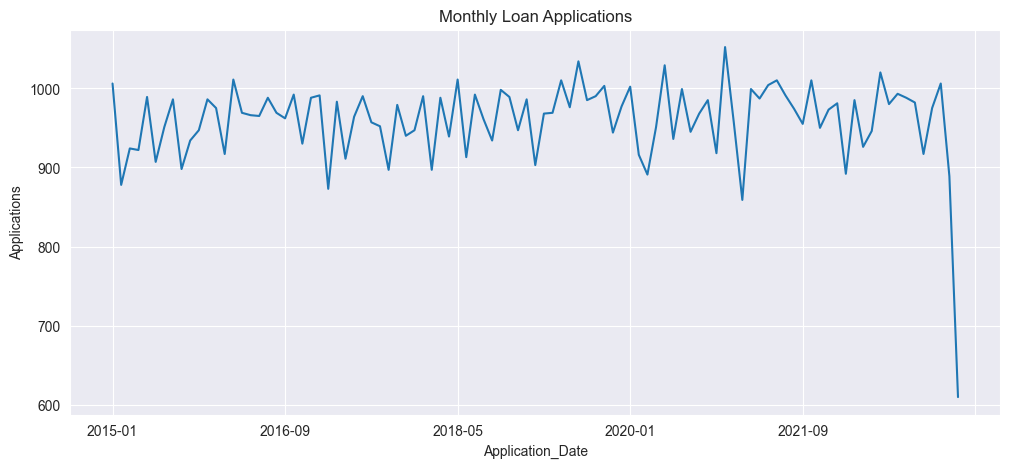

In [52]:
#Monthly loan applications
df["Application_Date"] = pd.to_datetime(df["Application_Date"])

monthly_apps = df.groupby(df["Application_Date"].dt.to_period("M")).size()
monthly_apps.index = monthly_apps.index.astype(str)

plt.figure(figsize=(12,5))
monthly_apps.plot()
plt.title("Monthly Loan Applications")
plt.ylabel("Applications")
plt.show()

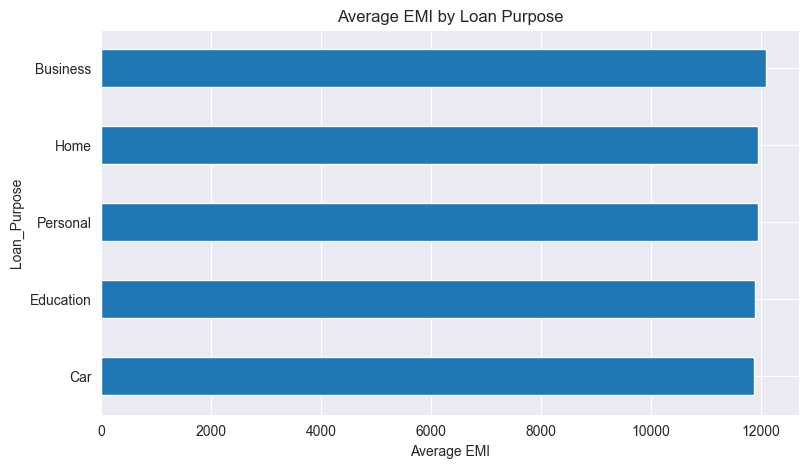

In [54]:
#Average EMI by loan purpose
emi_purpose = df.groupby("Loan_Purpose")["EMI"].mean().sort_values()

plt.figure(figsize=(9,5))
emi_purpose.plot(kind="barh")
plt.title("Average EMI by Loan Purpose")
plt.xlabel("Average EMI")
plt.show()

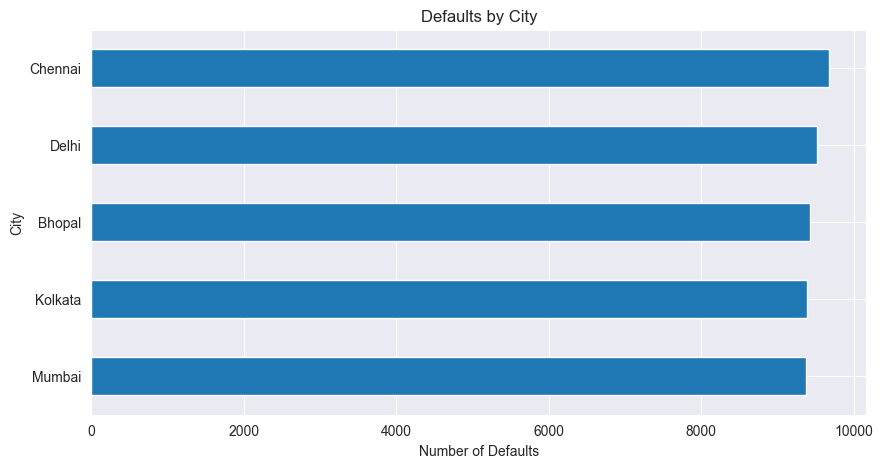

In [55]:
#Default count by city
default_city = df.groupby("City")["Default_Flag"].sum().sort_values()

plt.figure(figsize=(10,5))
default_city.plot(kind="barh")
plt.title("Defaults by City")
plt.xlabel("Number of Defaults")
plt.show()